# An unreliable supplier: late, short and capacity-limited deliveries

A garden centre sells two products all through the spring: bags of **compost** and packs of **seed trays**. Every morning, before opening, the buyer checks the stock on the shelf and on order and may order more from a regional **wholesaler**. The wholesaler normally delivers two mornings later.

Normally is the problem. Some deliveries arrive late, some arrive short, and on busy days the wholesaler cannot ship everything that was asked for. A **backup distributor** delivers the next morning, but costs more.

This notebook starts from the ordinary Stockcast run (one reliable supplier, fixed lead time) and adds one complication at a time:

1. the reliable wholesaler in the per-SKU API;
2. the *same* run written with `SupplyModel`, and with a pass-through `DeliveryOutcome` (identical results);
3. late deliveries;
4. short deliveries, and what the event ledger records about them;
5. wholesaler capacity, built from an ordinary ordering constraint;
6. a backup distributor: first taking what the wholesaler cannot ship, then chosen by the policy itself;
7. the per-supplier breakdown and a comparison of all runs.

[Notebook 05d](05d_open_orders_and_suppliers.ipynb) introduces open orders, `SupplyModel`, random lead times and supplier allocation. This notebook builds on it and does not repeat it.

The demand rates, supplier behaviour and prices below are invented for teaching. They are declared once, in the next cell, and never changed silently.

## 0. Setup: demand, prices and the order-up-to target

We simulate 10 weeks of daily demand. The first week is warm-up, the next eight weeks are scored and the last week is a settlement tail without new orders. A customer who finds no compost buys it elsewhere, so unmet demand is a **lost sale** (`allow_backorders=False`).

In [2]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stockcast.core import (
    ConstraintResult, DeliveryOutcome, InventoryStateDataFrame, OrderDecision,
    OrderingConstraint, OrderingConstraints, SimulationEngine, Supplier,
    SupplierAllocation, SupplyModel,
)
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, fill_rate, lost_sales_units, validate_event_frame,
)
from stockcast.policies import OrderUpToPolicy

origin = pd.Timestamp("2026-03-29")  # Sunday evening stock count; demand starts Monday
skus = ["compost", "seed_trays"]
rate = {"compost": 8.0, "seed_trays": 3.0}          # mean units sold per day (Poisson)
opening_stock = {"compost": 20.0, "seed_trays": 8.0}
lead_time = 2                                        # wholesaler: ordered today, on the shelf in 2 mornings
alpha = 0.95                                         # declared target probability
price = {"wholesaler": 4.0, "express": 5.5}          # purchase price per unit received
warmup, scoring, settlement = 7, 56, 7
n_periods = warmup + scoring + settlement

rng = np.random.default_rng(2026)
y = np.column_stack([rng.poisson(rate[sku], n_periods) for sku in skus]).astype(float)
demand = pd.DataFrame({
    "unique_id": np.tile(skus, n_periods),
    "period": np.repeat(np.arange(n_periods), len(skus)),
    "date": np.repeat(pd.date_range(origin + pd.Timedelta(days=1), periods=n_periods), len(skus)),
    "y": y.reshape(-1),
})
demand.head(4)

,unique_id,period,date,y
0,compost,0,2026-03-30,9.0
1,seed_trays,0,2026-03-30,6.0
2,compost,1,2026-03-31,12.0
3,seed_trays,1,2026-03-31,2.0


The buyer reviews every morning (`R = 1`) and raises the inventory position (on hand + on order) to a target `S`. An order placed today arrives `L = 2` mornings later, and then has to last until the next order arrives, so the target covers `H = L + R = 3` days of demand. With Poisson demand the 3-day total is Poisson with mean `3 × rate`, and `S` is its 95% quantile: a direct quantile of cumulative demand, never a sum of daily quantiles.

This target is computed **for a two-day lead time**. Keep that in mind: later the supplier will not always keep to it.

In [3]:
def poisson_quantile(probability, mean):
    # Smallest k with P(N <= k) >= probability, for N ~ Poisson(mean).
    k, pmf = 0, math.exp(-mean)
    cdf = pmf
    while cdf < probability:
        k += 1
        pmf *= mean / k
        cdf += pmf
    return float(k)


def order_up_to(policy_class=OrderUpToPolicy):
    # Daily-review order-up-to policy with an external 3-day target (L + R).
    horizon = lead_time + 1
    targets = pd.DataFrame({
        "unique_id": skus,
        "S": [poisson_quantile(alpha, rate[sku] * horizon) for sku in skus],
        "target_end": origin + pd.Timedelta(days=horizon),
    })
    policy = policy_class(lead_time=lead_time, review_period=1, service_level=alpha,
                          allow_backorders=False)
    return policy.fit(
        targets, forecast_origin=origin, forecast_frequency="D", target_column="S",
        target_end_date_column="target_end", protection_horizon=horizon,
        target_source="external_direct", target_probability=alpha,
    )


def opening_state():
    # Sunday evening: stock on the shelf, and one wholesaler delivery due on each of the next two mornings.
    state = InventoryStateDataFrame(skus, max_lead_time=6, allow_backorders=False)
    state = state.initialize_from_observed(
        pd.DataFrame({"unique_id": skus, "units": [opening_stock[sku] for sku in skus]}),
        on_hand_column="units", start_date=origin,
    )
    state.data["in_transit"] = [np.array([8.0, 8.0, 0, 0, 0, 0]), np.array([3.0, 3.0, 0, 0, 0, 0])]
    return state


def run(policy=None, **options):
    # One engine run on the shared demand path; options are passed to SimulationEngine.run.
    return SimulationEngine().run(
        policy or order_up_to(), demand, opening_state(), n_periods, period_frequency="D",
        warmup_periods=warmup, scoring_periods=scoring, settlement_periods=settlement,
        order_during_settlement=False, demand_source_name="garden_centre_v1",
        random_seed=None, **options,
    )


pd.Series({sku: poisson_quantile(alpha, rate[sku] * 3) for sku in skus}, name="S (3-day 95% quantile)")

compost       32.0
seed_trays    14.0
Name: S (3-day 95% quantile), dtype: float64

`max_lead_time=6` gives the state room for six future mornings on order. Two would be enough for the reliable wholesaler; the extra room is for late deliveries later on. It does not change the reliable run.

## 1. The reliable wholesaler, in the familiar per-SKU API

In [4]:
reliable = run()
events = validate_event_frame(reliable.to_event_frame())  # stock, pipeline and lost-sales identities hold
events[["date", "unique_id", "starting_on_hand", "received_units", "demand",
        "lost_sales_units", "order_quantity", "on_order_end"]].head(6)

,date,unique_id,starting_on_hand,received_units,demand,lost_sales_units,order_quantity,on_order_end
0,2026-03-30,compost,20.0,8.0,9.0,0.0,0.0,8.0
1,2026-03-30,seed_trays,8.0,3.0,6.0,0.0,0.0,3.0
2,2026-03-31,compost,19.0,8.0,12.0,0.0,5.0,5.0
3,2026-03-31,seed_trays,5.0,3.0,2.0,0.0,6.0,6.0
4,2026-04-01,compost,15.0,0.0,4.0,0.0,12.0,17.0
5,2026-04-01,seed_trays,6.0,0.0,2.0,0.0,2.0,8.0


In [5]:
reliable.summary()

{'fill_rate': np.float64(0.98),
 'demand_period_service_level': 0.9279279279279279,
 'mean_ending_on_hand_per_sku_period': np.float64(5.901785714285714),
 'stockout_periods': 8,
 'total_order_units': np.float64(642.0),
 'order_event_count': 56,
 'sku_order_line_count': 111}

## 2. The same run, written with `SupplyModel` and a `DeliveryOutcome`

The per-SKU run has exactly one supplier who always delivers `lead_time` mornings after the order. Written with the order-level API that is one `Supplier` with the policy's lead time. The event ledger, history and final state are **identical**; only the order frame now names the supplier.

In [6]:
wholesaler = SupplyModel([Supplier("wholesaler", lead_time=lead_time)])
same = run(supply=wholesaler)

pd.testing.assert_frame_equal(same.to_event_frame(), reliable.to_event_frame())
pd.testing.assert_frame_equal(same.history, reliable.history)
pd.testing.assert_frame_equal(same.inventory.get_dataframe(), reliable.inventory.get_dataframe())
print("identical event ledger, history and final state")
same.to_order_frame().query("source == 'placed'").head(4)

identical event ledger, history and final state


,order_id,unique_id,supplier_id,source,order_period,order_date,due_period,due_date,lead_time,ordered_quantity,delivery_quantity,status
4,4,compost,wholesaler,placed,2.0,2026-03-31,4,2026-04-02,2.0,5.0,5.0,received
5,5,seed_trays,wholesaler,placed,2.0,2026-03-31,4,2026-04-02,2.0,6.0,6.0,received
6,6,compost,wholesaler,placed,3.0,2026-04-01,5,2026-04-03,2.0,12.0,12.0,received
7,7,seed_trays,wholesaler,placed,3.0,2026-04-01,5,2026-04-03,2.0,2.0,2.0,received


A **`DeliveryOutcome`** decides what actually arrives when a supplier's delivery falls due. The engine asks it at the start of the due morning, before receipt and before the buyer orders, so the buyer finds out about a problem only on the day, never in advance.

The base class lets everything arrive. Attaching it therefore changes nothing except that the ledger gains one column, `supplier_shortfall_units` (units due that never arrive), which is zero here. The order frame gains four columns that say what happened to each delivery.

In [7]:
passthrough = run(supply=SupplyModel(
    [Supplier("wholesaler", lead_time=lead_time, delivery=DeliveryOutcome())]
))
ledger = passthrough.to_event_frame()
assert (ledger["supplier_shortfall_units"] == 0).all()
pd.testing.assert_frame_equal(ledger.drop(columns="supplier_shortfall_units"), reliable.to_event_frame())
print("identical apart from a zero supplier_shortfall_units column")
passthrough.to_order_frame()[["order_id", "unique_id", "due_period", "scheduled_due_period",
                              "delivery_quantity", "received_quantity", "delayed_quantity",
                              "undelivered_quantity", "status"]].head(4)

identical apart from a zero supplier_shortfall_units column


,order_id,unique_id,due_period,scheduled_due_period,delivery_quantity,received_quantity,delayed_quantity,undelivered_quantity,status
0,0,compost,1,1,8.0,8.0,0.0,0.0,received
1,1,compost,2,2,8.0,8.0,0.0,0.0,received
2,2,seed_trays,1,1,3.0,3.0,0.0,0.0,received
3,3,seed_trays,2,2,3.0,3.0,0.0,0.0,received


## 3. Late deliveries

Our wholesaler is sometimes late. We write that down as a small `DeliveryOutcome`. Its `resolve(due, context)` receives one row per delivery due this morning and returns, per row:

- `received_quantity`: arrives now;
- `delayed_quantity` and `delay_periods`: stays on order and is due again that many mornings later (when it is asked about again);
- anything left over never arrives.

`context.rng` is a random generator seeded from the `SupplyModel`'s `random_seed`, so every run with the same seed sees the same supplier behaviour.

The class below covers both lateness and short deliveries; this step switches on only the lateness.

In [8]:
class UnreliableWholesaler(DeliveryOutcome):
    # Per due delivery, one random draw decides what happens:
    #   with probability p_late   -> the whole delivery slips `late_by` mornings;
    #   with probability p_short  -> only `short_fill` of it arrives (whole units, rounded down),
    #                                the rest is never delivered;
    #   otherwise                 -> it arrives in full, on time.
    # A delivery that already slipped once arrives in full (no endless delays).

    def __init__(self, p_late=0.0, late_by=2, p_short=0.0, short_fill=0.6):
        self.p_late, self.late_by = p_late, late_by
        self.p_short, self.short_fill = p_short, short_fill

    def resolve(self, due, context):
        draw = context.rng.random(len(due))
        first_try = (due["due_period"] == due["scheduled_due_period"]).to_numpy()
        late = first_try & (draw < self.p_late)
        short = first_try & ~late & (draw < self.p_late + self.p_short)
        quantity = due["quantity"].to_numpy()
        return due.assign(
            received_quantity=np.where(late, 0.0,
                                       np.where(short, np.floor(self.short_fill * quantity), quantity)),
            delayed_quantity=np.where(late, quantity, 0.0),
            delay_periods=self.late_by,
        )

    def get_config(self):
        # Recorded in the run manifest, so the supplier assumption travels with the results.
        return {"p_late": self.p_late, "late_by": self.late_by,
                "p_short": self.p_short, "short_fill": self.short_fill}


def unreliable(**behaviour):
    return SupplyModel(
        [Supplier("wholesaler", lead_time=lead_time, delivery=UnreliableWholesaler(**behaviour))],
        random_seed=7,
    )

Now 15% of deliveries arrive two mornings late. Watch the message: the engine warns that deliveries now arrive at a different time than the policy's `lead_time`.

In [9]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    late = run(supply=unreliable(p_late=0.15, late_by=2))
print(caught[0].message)

supplier deliveries arrive at times other than the policy's lead_time (2 periods). The policy's targets were set for that fixed lead time and are not adjusted, so its protection window does not describe this supply. Results are valid for this assumption; see 'Lead-time assumption' in the suppliers-and-open-orders guide.


**Why the warning?** The target `S` was sized for a 2-day lead time: it covers 3 days of demand. A late delivery arrives after 4 days, so the stock has to last 5. The engine does **not** change your target to fix that. The run is correct accounting of what happens with *this* target against *this* supplier, which is exactly the question here: how much does lateness cost if we keep planning as if the wholesaler were on time? But the "95%" on the target no longer describes this design.

If you want a target that plans for late deliveries, compute it outside Stockcast over the random window (e.g. from the demand over `L + R` with `L` random) and pass it in as usual. The warning is a standard Python warning; we have read it, so we silence it for the rest of the notebook.

In [10]:
warnings.filterwarnings("ignore", message="supplier deliveries arrive at times other")

late_orders = late.to_order_frame()
late_orders["days_late"] = late_orders["due_period"] - late_orders["scheduled_due_period"]
late_orders.query("status == 'disrupted' or days_late > 0")[
    ["order_id", "unique_id", "source", "scheduled_due_period", "due_period", "days_late",
     "delivery_quantity", "received_quantity", "delayed_quantity", "status"]
].head(6)

,order_id,unique_id,source,scheduled_due_period,due_period,days_late,delivery_quantity,received_quantity,delayed_quantity,status
14,14,compost,placed,9,9,0,8.0,0.0,8.0,disrupted
15,14,compost,delayed,9,11,2,8.0,8.0,0.0,received
22,21,seed_trays,placed,12,12,0,3.0,0.0,3.0,disrupted
23,21,seed_trays,delayed,12,14,2,3.0,3.0,0.0,received
24,22,compost,placed,13,13,0,8.0,0.0,8.0,disrupted
25,22,compost,delayed,13,15,2,8.0,8.0,0.0,received


Each late delivery appears twice: first on its scheduled morning as `disrupted` with everything in `delayed_quantity`, then as a follow-up row of the same `order_id` with `source == "delayed"`, due two mornings later, where it is received. Rows with `source == "placed"` are therefore exactly the original orders; the follow-ups never count an ordered unit twice. Nothing is lost: `supplier_shortfall_units` stays zero, and the delayed quantity simply stays on order in the meantime.

In [11]:
pd.DataFrame({
    "reliable": reliable.summary(),
    "15% late": late.summary(),
}).loc[["fill_rate", "stockout_periods", "mean_ending_on_hand_per_sku_period"]]

,reliable,15% late
fill_rate,0.980000,0.929231
stockout_periods,8.000000,9.000000
mean_ending_on_hand_per_sku_period,5.901786,5.419643


## 4. Short deliveries

Now lateness is off and one delivery in four arrives only 60% full. The missing 40% is **cancelled**: it never arrives, leaves stock on order, and the buyer sees the lower inventory position the next morning and orders again. (A supplier that still owes the rest is a `DeliveryOutcome` that *delays* the remainder instead; the same class shape covers both.)

In [12]:
short = run(supply=unreliable(p_short=0.25, short_fill=0.6))
short_events = validate_event_frame(short.to_event_frame())
short_events.query("supplier_shortfall_units > 0")[
    ["date", "unique_id", "starting_on_order", "received_units", "supplier_shortfall_units",
     "order_quantity", "on_order_end"]
].head(5)

,date,unique_id,starting_on_order,received_units,supplier_shortfall_units,order_quantity,on_order_end
16,2026-04-07,compost,15.0,4.0,4.0,15.0,22.0
20,2026-04-09,compost,20.0,9.0,6.0,18.0,23.0
21,2026-04-09,seed_trays,5.0,1.0,1.0,4.0,7.0
24,2026-04-11,compost,26.0,10.0,8.0,13.0,21.0
25,2026-04-11,seed_trays,6.0,2.0,2.0,3.0,5.0


The pipeline balance of every row includes the shortfall:

`on_order_end = starting_on_order − received_units − supplier_shortfall_units + order_quantity`

`validate_event_frame` checks it on every row, next to the unchanged stock and lost-sales identities. We check it by hand once as well. Note what does **not** change: `order_quantity` is still what the buyer ordered, so costs per order are charged on the order, and the shelf only ever sees what was received.

In [13]:
balance = (short_events["starting_on_order"] - short_events["received_units"]
           - short_events["supplier_shortfall_units"] + short_events["order_quantity"])
assert np.allclose(balance, short_events["on_order_end"])

# The order frame reconciles with the ledger: received and undelivered per SKU and morning.
orders = short.to_order_frame()
due = orders[orders["status"] != "open"]
by_row = (due.groupby(["unique_id", "due_period"])[["received_quantity", "undelivered_quantity"]].sum()
          .rename_axis(["unique_id", "period"]))  # a delivery's due period is the ledger's period
ledger_rows = short_events.set_index(["unique_id", "period"])[["received_units", "supplier_shortfall_units"]]
joined = by_row.join(ledger_rows, how="outer").fillna(0.0)
assert np.allclose(joined["received_quantity"], joined["received_units"])
assert np.allclose(joined["undelivered_quantity"], joined["supplier_shortfall_units"])
print("pipeline balance and order-frame reconciliation hold on every row")

pipeline balance and order-frame reconciliation hold on every row


Supplier metrics need no new API. The evaluator accepts any function of the event frame, so the **supplier fill rate** (share of due units that arrived) is a few lines. For a run without a `DeliveryOutcome` the column is absent because nothing can go missing; the function then returns 1.

In [14]:
def supplier_fill_rate(events, context=None):
    # Share of units that fell due and actually arrived.
    received = events["received_units"].sum()
    missing = events["supplier_shortfall_units"].sum() if "supplier_shortfall_units" in events else 0.0
    return float(received / (received + missing)) if received + missing > 0 else 1.0


def scorecard(result):
    evaluator = InventoryEvaluator().fit(result, window="scoring")
    return evaluator.evaluate([fill_rate, lost_sales_units, avg_on_hand, supplier_fill_rate], groupby=[])


pd.concat({"reliable": scorecard(reliable), "25% short": scorecard(short)})

,,fill_rate,lost_sales_units,avg_on_hand,supplier_fill_rate
reliable,0,0.980000,13.0,5.901786,1.000000
25% short,0,0.935385,42.0,4.946429,0.862216


## 5. Wholesaler capacity

On busy days the wholesaler can ship at most **14 units per morning**, compost and seed trays together. What happens to the rest is a business rule, so we decide it and write it down. First rule: **the excess is not ordered**. That is an ordinary ordering constraint, applied to the whole order before it goes to the supplier. When the order is too big, every SKU is scaled down by the same factor and rounded down to whole units.

No new object is needed. The ledger's constraint audit already records every cut: `constraint_adjustment_units`, `binding_constraints` and `capacity_violation_flag`.

In [15]:
class DailyCapacity(OrderingConstraint):
    # At most `limit` units per order, all SKUs together; a larger order is scaled down
    # proportionally and rounded down to whole units.
    name = "wholesaler_capacity"

    def __init__(self, limit):
        self.limit = float(limit)

    def apply(self, order, context):
        frame = order.get_dataframe()
        requested = frame["order_quantity"].to_numpy(dtype=float)
        total = requested.sum()
        factor = min(1.0, self.limit / total) if total > 0 else 1.0
        final = np.floor(requested * factor) if factor < 1.0 else requested
        frame["order_quantity"] = final
        cut = ~np.isclose(requested, final)
        audit = pd.DataFrame({
            "unique_id": frame[order.sku_column], "requested_order_quantity": requested,
            "constrained_order_quantity": final, "constraint_adjustment_units": final - requested,
            "constraint_binding_flag": cut, "capacity_violation_flag": cut,
            "binding_constraints": [self.name if flag else "" for flag in cut],
        })
        return ConstraintResult(OrderDecision(frame, lead_time=order.lead_time,
                                              review_period=order.review_period), audit)

    def to_manifest(self):
        return {"class": type(self).__name__, "name": self.name, "limit": self.limit}


capacity = OrderingConstraints([DailyCapacity(14)])
capped = run(supply=unreliable(p_late=0.15, p_short=0.25), order_constraints=capacity)
capped_events = capped.to_event_frame()
capped_events.query("capacity_violation_flag")[
    ["date", "unique_id", "requested_order_quantity", "order_quantity",
     "constraint_adjustment_units", "binding_constraints"]
].head(4)

,date,unique_id,requested_order_quantity,order_quantity,constraint_adjustment_units,binding_constraints
10,2026-04-04,compost,9.0,7.0,-2.0,wholesaler_capacity
11,2026-04-04,seed_trays,7.0,6.0,-1.0,wholesaler_capacity
14,2026-04-06,compost,7.0,6.0,-1.0,wholesaler_capacity
15,2026-04-06,seed_trays,8.0,7.0,-1.0,wholesaler_capacity


In [16]:
unreliable_only = run(supply=unreliable(p_late=0.15, p_short=0.25))
pd.concat({
    "late + short": scorecard(unreliable_only),
    "late + short + capacity 14": scorecard(capped),
}).assign(capacity_cut_sku_days=[0, int(capped.to_event_frame("scoring")["capacity_violation_flag"].sum())])

,,fill_rate,lost_sales_units,avg_on_hand,supplier_fill_rate,capacity_cut_sku_days
late + short,0,0.909231,59.0,4.491071,0.890244,0
late + short + capacity 14,0,0.886154,74.0,3.955357,0.882171,36


## 6. A backup distributor

The distributor (`express`) delivers the next morning, always in full, at a higher price. We add it in two ways.

### 6a. The distributor takes what the wholesaler cannot ship

This is the second capacity rule: **the excess goes to another supplier**. Deciding which supplier ships what is the job of a `SupplierAllocation`, so we write one. The wholesaler gets up to 14 units (shared proportionally across SKUs), and the distributor gets the rest. No ordering constraint is used now: the buyer's full order is placed.

In [17]:
class CapacityThenBackup(SupplierAllocation):
    # The main supplier takes at most `capacity` units per order (all SKUs, proportionally,
    # whole units); the backup supplier takes the rest.
    def __init__(self, main, backup, capacity):
        self.main, self.backup, self.capacity = main, backup, float(capacity)

    def allocate(self, orders, context):
        quantity = orders["order_quantity"].to_numpy(dtype=float)
        share = min(1.0, self.capacity / quantity.sum())
        main = np.floor(quantity * share) if share < 1.0 else quantity
        rows = [
            (sku, supplier, amount)
            for sku, main_part, total in zip(orders[context.sku_column], main, quantity)
            for supplier, amount in [(self.main, main_part), (self.backup, total - main_part)]
            if amount > 0
        ]
        return pd.DataFrame(rows, columns=[context.sku_column, "supplier_id", "order_quantity"])

    def get_config(self):
        return {"main": self.main, "backup": self.backup, "capacity": self.capacity}


def two_suppliers(allocation):
    return SupplyModel(
        [Supplier("wholesaler", lead_time=lead_time,
                  delivery=UnreliableWholesaler(p_late=0.15, p_short=0.25)),
         Supplier("express", lead_time=1)],
        allocation=allocation, random_seed=7,
    )


spill = run(supply=two_suppliers(CapacityThenBackup("wholesaler", "express", 14)))
validate_event_frame(spill.to_event_frame())
spill_orders = spill.to_order_frame()
pd.DataFrame({
    # Ordered: the original order rows. Received / never delivered: every row, incl. delayed follow-ups.
    "ordered": spill_orders.query("source == 'placed'").groupby("supplier_id")["delivery_quantity"].sum(),
    "received": spill_orders.groupby("supplier_id")["received_quantity"].sum(),
    "never_delivered": spill_orders.groupby("supplier_id")["undelivered_quantity"].sum(),
})

,ordered,received,never_delivered
supplier_id,,,
express,60.0,60.0,0.0
wholesaler,681.0,604.0,77.0


Note that the distributor's one-day lead time is also different from the policy's two days. Orders sent there arrive a day earlier than the target assumed, so the warning would fire here too.

### 6b. The policy chooses the supplier

Instead of splitting by capacity, the buyer can decide per product each morning: **expedite** from the distributor when the shelf is nearly empty, otherwise use the wholesaler. The decision belongs to the policy, so the policy writes it into its order decision as an extra `supplier_id` column. Every allocation receives the accepted decision as `context.decision`, so a three-line allocation follows the policy's choice.

In [18]:
class ExpediteWhenLow(OrderUpToPolicy):
    # Order-up-to as before; additionally names the supplier per SKU.
    # Express when less than one day of average demand is on the shelf.
    def predict(self, inventory_state_df, *, current_period, **kwargs):
        decision = super().predict(inventory_state_df, current_period=current_period, **kwargs)
        frame = decision.get_dataframe()
        on_hand = inventory_state_df.get_dataframe().set_index("unique_id")["on_hand"]
        low = frame["unique_id"].map(on_hand) < frame["unique_id"].map(rate)
        frame["supplier_id"] = np.where(low, "express", "wholesaler")
        return OrderDecision(frame, lead_time=decision.lead_time, review_period=decision.review_period)


class FollowPolicy(SupplierAllocation):
    # Each SKU's whole order goes to the supplier the policy named.
    def allocate(self, orders, context):
        chosen = context.decision.set_index(context.sku_column)["supplier_id"]
        return orders.assign(supplier_id=orders[context.sku_column].map(chosen))


chosen = run(order_up_to(ExpediteWhenLow), supply=two_suppliers(FollowPolicy()))
validate_event_frame(chosen.to_event_frame())
chosen.to_order_frame().query("source == 'placed'")["supplier_id"].value_counts()

supplier_id
wholesaler    111
express        13
Name: count, dtype: int64

This is a simple heuristic rule, not an optimized dual-sourcing policy: the target still covers a 2-day lead time, and the threshold is a declared guess. It only shows how a policy's own choice reaches the supply stage.

## 7. Who shipped what, and a comparison

The event ledger has one row per SKU and morning, so it keeps one `order_quantity`. The per-supplier detail lives in the order frame, and it adds up: for every SKU and morning, `wholesaler + express = total = order_quantity`.

In [19]:
orders = spill.to_order_frame()
placed = orders[orders["source"] == "placed"]
split = placed.pivot_table(index=["unique_id", "order_period"], columns="supplier_id",
                           values="delivery_quantity", aggfunc="sum", fill_value=0.0)
split["total"] = split["wholesaler"] + split["express"]
ledger_orders = spill.to_event_frame().set_index(["unique_id", "period"])["order_quantity"]
assert np.allclose(split["total"], ledger_orders.loc[split.index])
split.head(6)

supplier_id             express  wholesaler  total
unique_id order_period                            
compost   2.0               0.0         5.0    5.0
          3.0               0.0        12.0   12.0
          4.0               0.0         4.0    4.0
          5.0               0.0        11.0   11.0
          6.0               2.0         7.0    9.0
          7.0               0.0         8.0    8.0

With several suppliers the ledger's `sku_order_line_count` counts **supplier lines**: an order split between two suppliers is two purchase lines. So a fixed ordering cost per line is paid twice, once per supplier, which is usually what a per-order fee means. For a cost per replenishment decision, use `order_event_count` instead.

Finally, all runs side by side. Purchase cost is charged per unit **received**, at the declared prices; undelivered units are not paid for. That is our pricing assumption, computed from the order frame.

In [20]:
def purchase_cost_received(result):
    # Declared assumption: pay the supplier's price for every unit received (scoring window).
    orders = result.to_order_frame()
    first, last = warmup + 1, warmup + scoring  # state periods of the scoring window
    orders = orders[(orders["due_period"] >= first) & (orders["due_period"] <= last)]
    orders = orders[orders["status"] != "open"]
    if "received_quantity" in orders:
        received = orders["received_quantity"]
    else:
        received = orders["delivery_quantity"]
    supplier = orders["supplier_id"].fillna("wholesaler")  # opening stock came from the wholesaler
    return float((received * supplier.map(price)).sum())


runs = {
    "1 reliable": reliable,
    "3 late 15%": late,
    "4 short 25%": short,
    "5 late + short, capacity 14": capped,
    "6a + express takes the excess": spill,
    "6b + policy expedites when low": chosen,
}
comparison = pd.concat({name: scorecard(result) for name, result in runs.items()})
comparison["purchase_cost"] = [purchase_cost_received(result) for result in runs.values()]
comparison.droplevel(1).round(3)

,fill_rate,lost_sales_units,avg_on_hand,supplier_fill_rate,purchase_cost
1 reliable,0.980,13.0,5.902,1.000,2544.0
3 late 15%,0.929,46.0,5.420,1.000,2412.0
4 short 25%,0.935,42.0,4.946,0.862,2428.0
"5 late + short, capacity 14",0.886,74.0,3.955,0.882,2276.0
6a + express takes the excess,0.915,55.0,4.902,0.892,2453.5
6b + policy expedites when low,0.928,47.0,4.938,0.918,2634.0


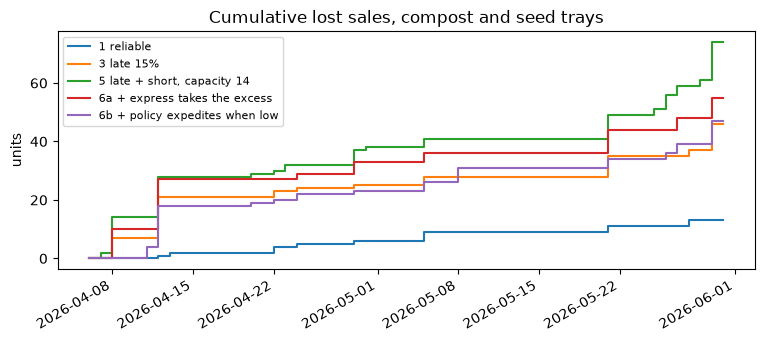

In [21]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for name in ["1 reliable", "3 late 15%", "5 late + short, capacity 14",
             "6a + express takes the excess", "6b + policy expedites when low"]:
    # Lost sales of both products, accumulated over the scored weeks.
    ev = runs[name].to_event_frame("scoring")
    lost = ev.groupby("date")["lost_sales_units"].sum().cumsum()
    ax.step(lost.index, lost.to_numpy(), where="post", label=name)
ax.set_title("Cumulative lost sales, compost and seed trays")
ax.set_ylabel("units")
ax.legend(loc="upper left", fontsize=8)
fig.autofmt_xdate()
plt.show()

Every supplier problem adds lost sales, because the target still plans for an on-time, full delivery. Capacity on top of an unreliable wholesaler is the worst case. Sending the excess to the distributor recovers part of that loss, and letting the policy expedite when the shelf is low recovers more, at the highest purchase cost. This is one seeded demand path and one invented supplier; it shows how to set up the comparison, not a general ranking of the options.

## What this notebook assumed

- Demand is Poisson with known rates; targets are direct 95% quantiles of 3-day demand for a **2-day** lead time and are never adjusted for the supplier's behaviour.
- The wholesaler's behaviour is invented: 15% of deliveries two mornings late, 25% delivered 60% full, the missing part cancelled, at most one slip per delivery. It is drawn per delivery from the `SupplyModel` seed (`random_seed=7`), so every run is reproducible.
- A delivery's fate is known only on its due morning. Until then the buyer sees it on order at its full quantity.
- Capacity: 14 units per morning, all SKUs together, shared proportionally. In step 5 the excess is not ordered; in step 6a it goes to the distributor.
- The distributor always delivers in full, the next morning. Prices are per unit received.
- Lost sales, no backorders. Opening stock and the opening pipeline are declared in `opening_state()`.

What is *not* modelled: supplier-specific minimum orders, prices that depend on volume, correlation between the two suppliers, and targets that account for random lead times. Each of these can be added with the same objects: a `DeliveryOutcome`, a `SupplierAllocation`, an `OrderingConstraint`, or a custom policy.